<a href="https://colab.research.google.com/github/thunderbolt190/Goodman-Weare-MCMC-using-JAX/blob/main/Goodman_Weare_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np

mean = np.array([2.0, -1.0])

covar = np.array([[1.0, 0.8], [0.8, 1.0]])
covinv = np.linalg.inv(covar)

def log_prob(x):
  diff = x - mean
  return -0.5 * diff.T @ covinv @ diff

print(log_prob(np.array([2.0, -1.0])))

print(log_prob(np.array([0.0, 0.0])))

print(log_prob(np.array([10.0, 10.0])))

0.0
-11.388888888888893
-61.388888888888914


In [4]:
rng = np.random.default_rng(42)

current = np.array([2.0, -1.0])

def proposal_step(current, step_size, rng = rng):
  noise = rng.normal(loc = 0.0, scale = step_size, size = current.shape)
  return current + noise

print(proposal_step(current, step_size=0.1, rng=rng))

print(proposal_step(current, step_size=5.0, rng=rng))

[ 2.03047171 -1.10399841]
[5.75225598 3.70282358]


In [5]:
def accept(current_log_prob, proposal_log_prob, rng = rng):
  log_a = proposal_log_prob - current_log_prob
  log_u = np.log(rng.uniform())
  return log_u < log_a
# This gives ~50% because log_a = log(0.5) ≈ -0.69
# so you accept when log_u < -0.69, which happens ~50% of the time
results = [accept(-5.0, -5.693, rng) for _ in range(100)]
print(sum(results), "/ 100 accepted")  # should be roughly 50

53 / 100 accepted


In [6]:
def rwmh(log_prob_fn, init, n_steps, step_size, rng):
  chain = np.zeros((n_steps, init.shape[0]))
  current = init.copy()
  curr_log_prob = log_prob_fn(current)
  acc_counter = 0
  for i in range(n_steps):
    proposal = proposal_step(current, step_size, rng)
    prop_log_prob = log_prob_fn(proposal)
    if accept(curr_log_prob, prop_log_prob, rng):
      curr_log_prob = prop_log_prob
      current = proposal
      acc_counter += 1
    chain[i] = current
  return chain, acc_counter / n_steps

In [7]:
rng  = np.random.default_rng(42)
init = np.array([0.0, 0.0])

chain, accept_rate = rwmh(
    log_prob_fn = log_prob,
    init        = init,
    n_steps     = 50_000,
    step_size   = 1.0,
    rng         = rng
)

print(f"Acceptance rate: {accept_rate:.2%}")
print(f"Chain shape: {chain.shape}")

Acceptance rate: 40.34%
Chain shape: (50000, 2)


In [8]:
for step_size in [0.01, 0.1, 1.0, 5.0, 20.0]:
    rng = np.random.default_rng(42)
    chain, rate = rwmh(log_prob, init, n_steps=10_000,
                       step_size=step_size, rng=rng)
    print(f"step_size={step_size:5.2f}  acceptance={rate:.2%}")

step_size= 0.01  acceptance=98.52%
step_size= 0.10  acceptance=91.88%
step_size= 1.00  acceptance=40.67%
step_size= 5.00  acceptance=4.00%
step_size=20.00  acceptance=0.26%


In [10]:
burnin = 1000
samples = chain[burnin:]

sample_mean = samples.mean(axis=0)
sample_cov  = np.cov(samples.T)

print(f"True mean:   {mean}")
print(f"Sample mean: {sample_mean.round(3)}")

print(f"\nTrue covariance:\n{covar}")
print(f"\nSample covariance:\n{sample_cov.round(3)}")

True mean:   [ 2. -1.]
Sample mean: [ 2.108 -0.809]

True covariance:
[[1.  0.8]
 [0.8 1. ]]

Sample covariance:
[[0.709 0.667]
 [0.667 1.159]]


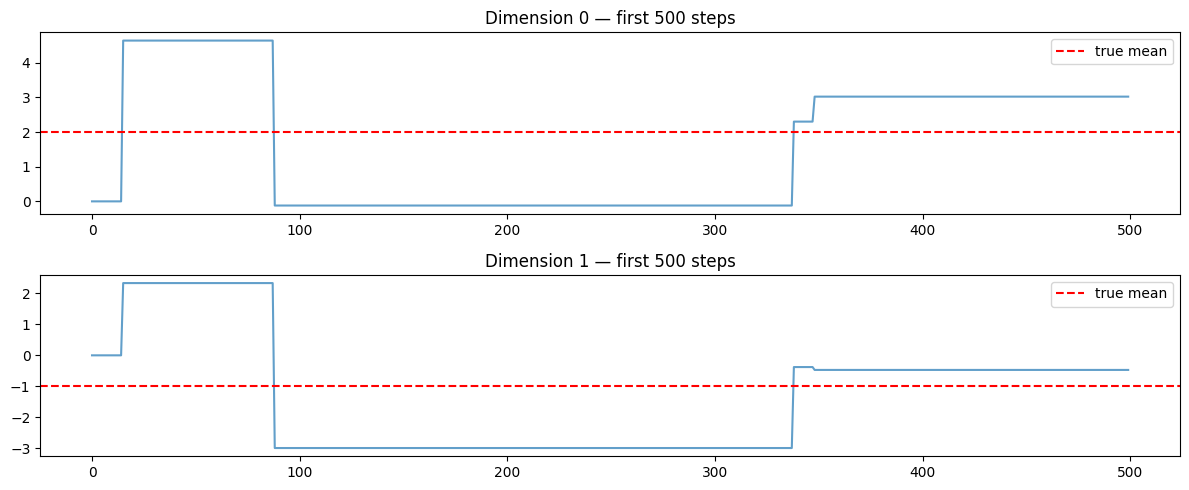

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].plot(chain[:500, 0], alpha=0.7)
axes[0].axhline(mean[0], color='r', linestyle='--', label='true mean')
axes[0].set_title("Dimension 0 — first 500 steps")
axes[0].legend()

axes[1].plot(chain[:500, 1], alpha=0.7)
axes[1].axhline(mean[1], color='r', linestyle='--', label='true mean')
axes[1].set_title("Dimension 1 — first 500 steps")
axes[1].legend()

plt.tight_layout()
plt.show()

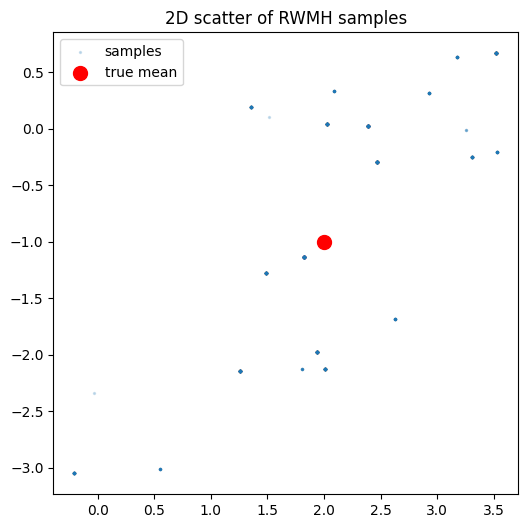

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(samples[::10, 0], samples[::10, 1],
            alpha=0.2, s=2, label='samples')
plt.scatter(*mean, color='red', s=100, zorder=5, label='true mean')
plt.title("2D scatter of RWMH samples")
plt.legend()
plt.show()

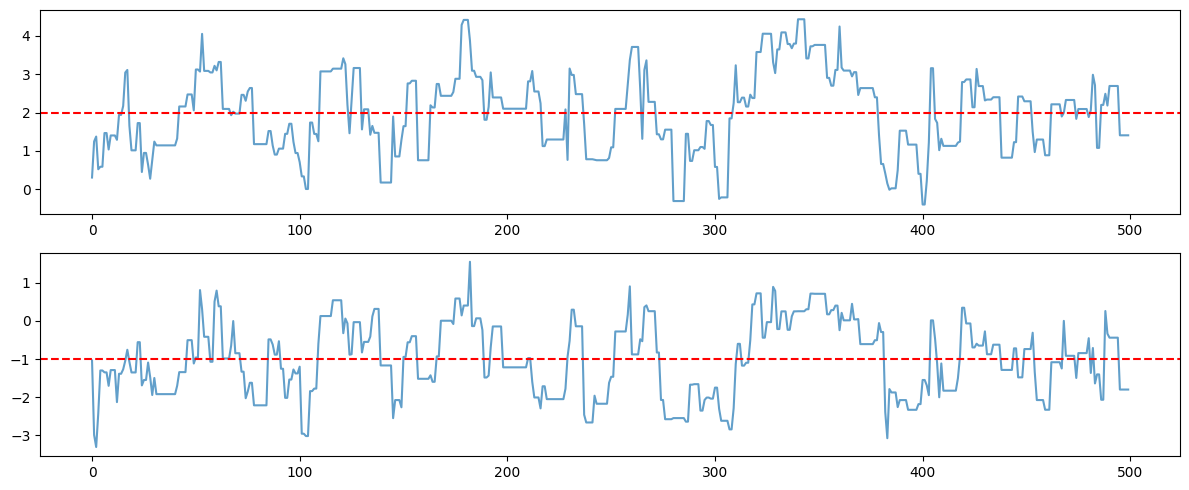

In [20]:
rng = np.random.default_rng(42)
chain, rate = rwmh(log_prob, init, n_steps=50_000, step_size=1, rng=rng)
samples = chain[1000:]

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(chain[:500, 0], alpha=0.7)
axes[0].axhline(mean[0], color='r', linestyle='--', label='true mean')
axes[1].plot(chain[:500, 1], alpha=0.7)
axes[1].axhline(mean[1], color='r', linestyle='--', label='true mean')
plt.tight_layout()
plt.show()

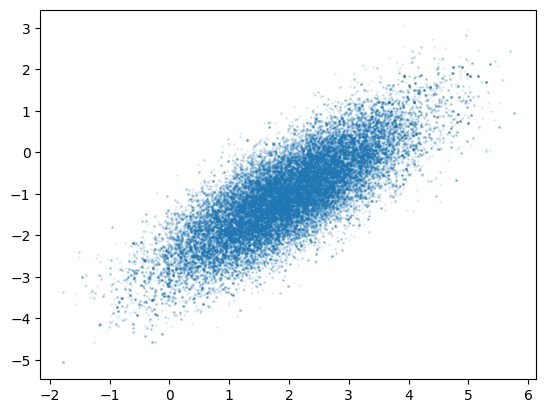

In [14]:
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.1, s=1)

In [15]:
burnin = 1000
samples = chain[burnin:]

print(f"True mean:   {mean}")
print(f"Sample mean: {samples.mean(axis=0).round(3)}")

print(f"\nTrue covariance:\n{covar}")
print(f"\nSample covariance:\n{np.cov(samples.T).round(3)}")

True mean:   [ 2. -1.]
Sample mean: [ 1.985 -1.028]

True covariance:
[[1.  0.8]
 [0.8 1. ]]

Sample covariance:
[[1.042 0.83 ]
 [0.83  1.015]]


In [34]:
def sample_stretch_factor(rng, n_samples, a = 2.0):
  unif = rng.uniform(size = n_samples)
  samples = (unif * (np.sqrt(a) - 1 / np.sqrt(a)) + 1 / np.sqrt(a)) ** 2
  return samples


In [35]:
z_samples = sample_stretch_factor(rng, n_samples=10_000)
print(f"Min: {z_samples.min():.3f}")   # should be >= 0.5
print(f"Max: {z_samples.max():.3f}")   # should be <= 2.0

Min: 0.500
Max: 2.000


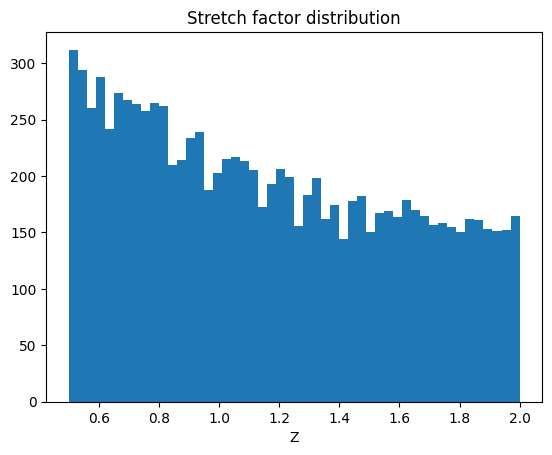

In [36]:
plt.hist(z_samples, bins=50)
plt.title("Stretch factor distribution")
plt.xlabel("Z")
plt.show()

In [37]:
print(f"Mean: {z_samples.mean():.3f}")


Mean: 1.162


In [38]:
def gw_proposal(walker_i, walker_j, z):
  return walker_j + z * (walker_i - walker_j)

In [39]:
wi = np.array([1.0, 2.0])
wj = np.array([3.0, 4.0])

print(gw_proposal(wi, wj, z=1.0))  # should be [1.0, 2.0]
print(gw_proposal(wi, wj, z=2.0))  # should be [-1.0, 0.0]
print(gw_proposal(wi, wj, z=0.5))

[1. 2.]
[-1.  0.]
[2. 3.]


In [40]:
def gw_accept(current_log_prob, proposal_log_prob, z, dim, rng):
  log_a = (dim - 1) * np.log(z) + proposal_log_prob - current_log_prob
  log_u = np.log(rng.uniform())
  return log_u < log_a

In [42]:
# Check 1: when proposal is much better, should almost always accept
print(gw_accept(-10.0, -0.1, z=1.0, dim=2, rng=rng))  # True

# Check 2: when proposal is much worse, should almost always reject
print(gw_accept(-0.1, -10.0, z=1.0, dim=2, rng=rng))  # False

# Check 3: when z=1 and dim=2, (dim-1)*log(z) = 1*log(1) = 0
# so it should behave identically to RWMH accept
# verify the Z term vanishes
log_alpha = (2-1) * np.log(1.0) + (-5.0) - (-5.0)
print(log_alpha)   # should be 0.0

True
False
0.0


In [43]:
def select_complementary(n_walkers, i, rng):
  possible = np.arange(n_walkers)
  possible = np.delete(possible, i)
  return rng.choice(possible)


In [44]:
i = 5
results = [select_complementary(10, i, rng) for _ in range(1000)]

print(f"Min: {min(results)}")         # should be 0
print(f"Max: {max(results)}")         # should be 9
print(f"i appears: {results.count(5)}")  # should be 0
print(f"Unique values: {sorted(set(results))}")  # should be 0-9 excluding 5

Min: 0
Max: 9
i appears: 0
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [57]:
def goodman_weare(log_prob_fn, init_walkers, n_steps, rng, a = 2.0):
  n_walkers = init_walkers.shape[0]
  dim = init_walkers.shape[1]
  chain = np.zeros((n_steps, n_walkers, dim))
  current = init_walkers.copy()
  log_probs = np.apply_along_axis(log_prob, axis=1, arr=init_walkers)
  acc_counter = 0
  for i in range(n_steps):
    for j in range(n_walkers):
      comp_walker = select_complementary(n_walkers, j, rng)
      z = sample_stretch_factor(rng, 1, a)[0]
      proposal = gw_proposal(current[j], current[comp_walker], z)
      prop_log_prob = log_prob_fn(proposal)
      if gw_accept(log_probs[j], prop_log_prob, z, dim, rng):
        current[j] = proposal
        log_probs[j] = prop_log_prob
        acc_counter += 1
    chain[i] = current
  return chain, acc_counter / (n_walkers * n_steps)

In [58]:
rng = np.random.default_rng(42)
n_walkers = 50
dim = 2
init_walkers = rng.normal(0, 1, size=(n_walkers, dim))

chain_gw, accept_rate_gw = goodman_weare(
    log_prob_fn  = log_prob,
    init_walkers = init_walkers,
    n_steps      = 2_000,
    rng          = rng
)

print(f"Acceptance rate: {accept_rate_gw:.2%}")
print(f"Chain shape: {chain_gw.shape}")

Acceptance rate: 71.42%
Chain shape: (2000, 50, 2)


In [51]:
z = 1.2
current_lp = -3.0
proposal_lp = -3.5   # worse proposal

log_a = (dim - 1) * np.log(z) + proposal_lp - current_lp
print(log_a)

-0.31767844320604555


In [59]:
burnin = 200
flat_samples = chain_gw[burnin:].reshape(-1, dim)

print(f"Number of samples: {len(flat_samples)}")
print(f"\nTrue mean:   {mean}")
print(f"Sample mean: {flat_samples.mean(axis=0).round(3)}")
print(f"\nTrue covariance:\n{covar}")
print(f"\nSample covariance:\n{np.cov(flat_samples.T).round(3)}")

Number of samples: 90000

True mean:   [ 2. -1.]
Sample mean: [ 1.973 -1.023]

True covariance:
[[1.  0.8]
 [0.8 1. ]]

Sample covariance:
[[0.992 0.797]
 [0.797 1.   ]]


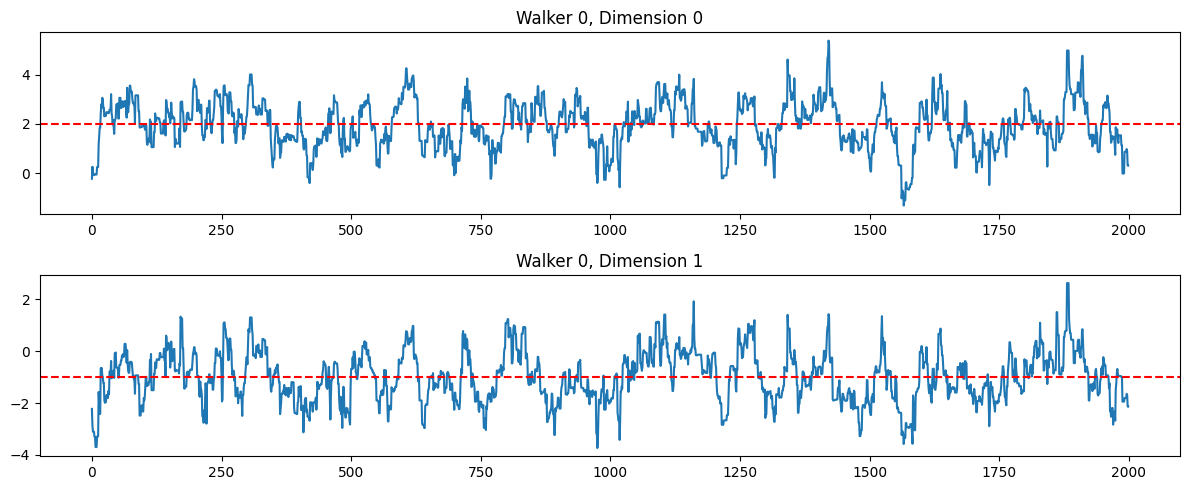

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(chain_gw[:, 0, 0])
axes[0].axhline(mean[0], color='r', linestyle='--', label='true mean')
axes[0].set_title("Walker 0, Dimension 0")
axes[1].plot(chain_gw[:, 0, 1])
axes[1].axhline(mean[1], color='r', linestyle='--', label='true mean')
axes[1].set_title("Walker 0, Dimension 1")
plt.tight_layout()
plt.show()